# Run adaptive immune system with noisy pMHCs

In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from stoch_sim_model import *
from joint_plot_grid_nb import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

### (1) Plot sample trajectory

In [2]:
# Run single simulation
I_0 = 10
N_0 = 50

infection_type = "prim" #"prim", "sec"
sim_type = "agent" #"pop_ode", "agent"
reg = np.array([1.0, 0.0, -1.0, -1.0, 1.0, -1.0])

regs, dyn, ts, lin_comp, p_diff, Eff, mycNa, mycpMa,myccM, mycEin, mycEout = agent_stoch_sim(I_0 = I_0, d_I = 1.0, N_0 = N_0, d_IE = d_IE, 
                                                                                             d_IH = d_IH, K_IE = K_IE,
                                                                                             regulation_coeffs =  reg,
                                                                                             infection = infection_type,
                                                                                             reg_model = "mwc_like")

S, I, A, N, E, cM, eM, H, I_d_I, I_d_IE = dyn[:,-10], dyn[:,-9], dyn[:,-8], dyn[:,-7], dyn[:,-6], dyn[:,-5], dyn[:,-4], dyn[:,-3], dyn[:,-2], dyn[:,-1]

In [3]:
reg_string = '-'.join((reg * 1).astype('U1'))

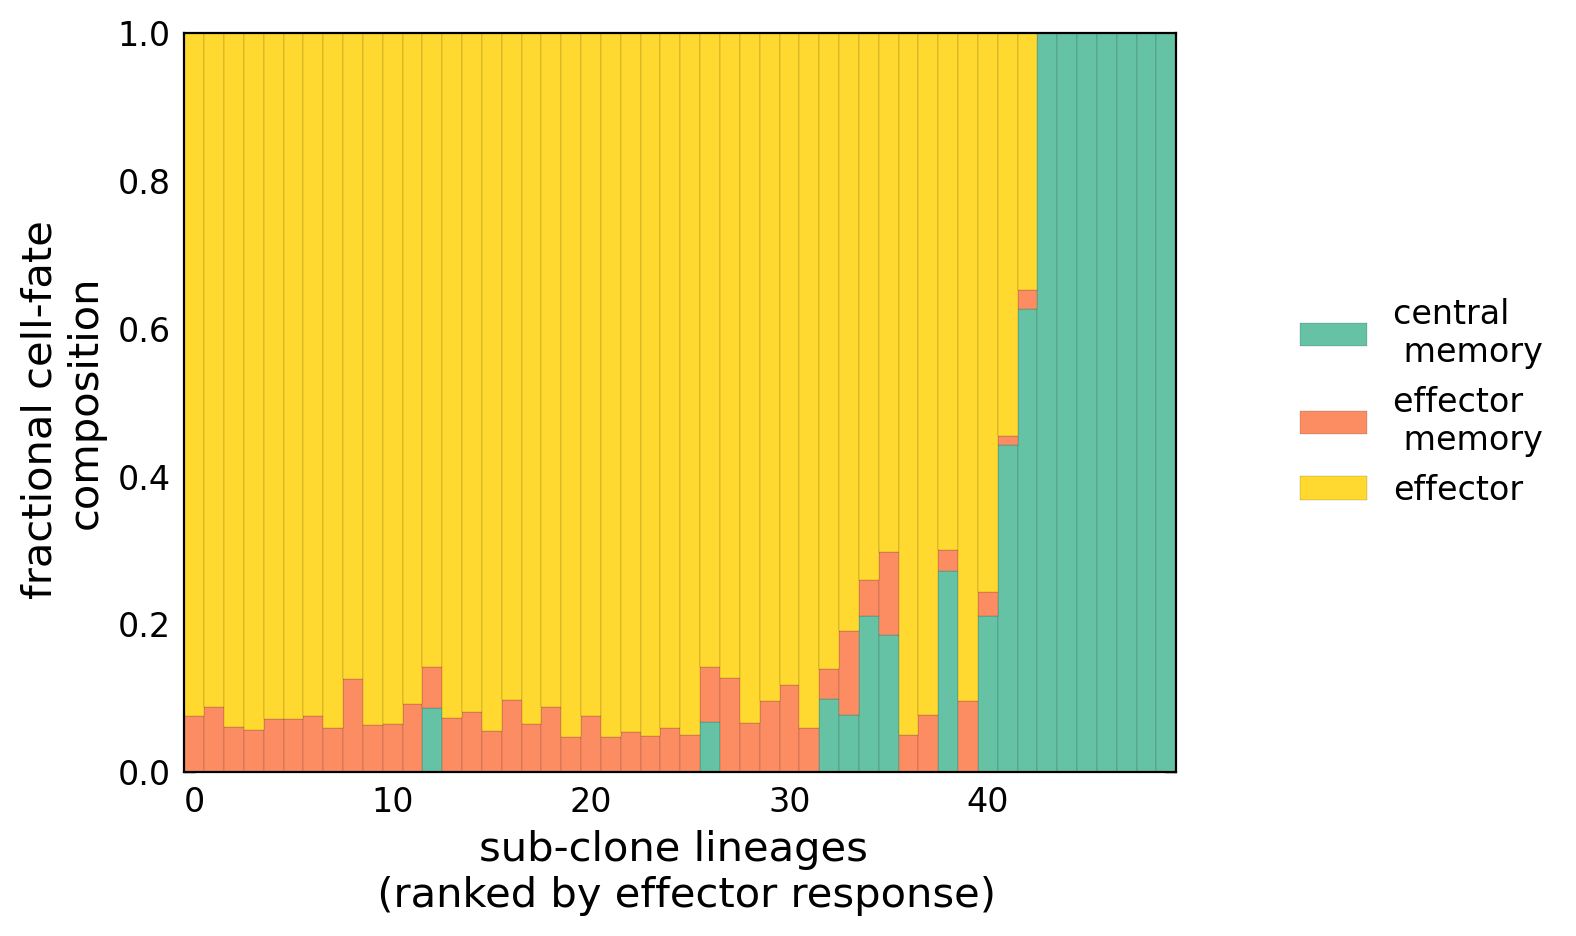

In [4]:
keys = np.array(['naive', 'primary mem.', 'central \n memory', 'effector', 'effector \n memory'])[2:]
all_counts = lin_comp[2:-2].T
effector_ranking = np.argsort(all_counts[:, 1])[::-1]
all_counts = all_counts[effector_ranking]
total_counts = all_counts.sum(axis=1)
norm_counts = all_counts / total_counts[:, None]
norm_counts[~np.isfinite(norm_counts)] = 0
comp_argsort = np.argsort(np.max(all_counts, axis=0))
bar_dict = {k: v for k, v in zip(keys[comp_argsort], norm_counts.T[comp_argsort])}
lineage_idxs = np.arange(all_counts.shape[0])

fig, ax = plt.subplots()
bottom = np.zeros(len(lineage_idxs))
cmap_colors = sns.color_palette('Set2', 10)
cmap_colors = [cmap_colors[i]
               for i in [0, 1, 5]]#[7, 2, 0, 1, 5]]
# cmap_colors = [cmap_colors[i]
#                for i in [6, 1, 2, 5, 0]]
width = 1

for i, (celltype, fraction) in enumerate(bar_dict.items()):
    ax.bar(lineage_idxs, fraction, width,
           edgecolor='k', linewidth=0.05,
           label=celltype, bottom=bottom, color=cmap_colors[i])
    bottom += fraction
    
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5), fontsize = 12)
ax.set_xlim(-0.5, len(all_counts) - 0.5)
ax.set_xlabel('sub-clone lineages \n (ranked by effector response)', fontsize = 15)
ax.set_ylabel('fractional cell-fate \ncomposition', fontsize = 15)
#ax.set_yscale('log')

ax.set_xticks(np.arange(0, N_0, 10))
ax.set_xticklabels(ax.get_xticks(), fontsize=12)

ax.set_yticks(np.round(np.arange(0, 1.2, 0.2), 1))
ax.set_yticklabels(ax.get_yticks(), fontsize=12)

fig.savefig("_figs/"+infection_type+'-'+'fates-by-lin-'+reg_string+'.png', dpi=300, bbox_inches="tight")

In [ ]:
print(np.amax(cM + eM)/np.amax(E))
#print(E[np.argmax(E):np.argmax(E)+500])
plt.plot(ts, Eff)
plt.semilogy()
np.max(Eff)

0.12698640972172287


21843

In [ ]:
#plt.plot(ts, Eff)
#plt.plot(ts, mycpMa, 'k')
plt.plot(ts, mycEin) #, 'r--')
plt.plot(ts, mycEout, 'b.')
plt.axhline(y = myc_thresh, color = 'k', linestyle = '--')
#plt.plot(ts[0:1000], S[0:1000])
plt.semilogy()
print(np.amax(mycEout))

In [ ]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = True, figsize=(5,5))

ax1.plot(ts, S, 'k', label = r'susceptible, $S$')
ax1.plot(ts, I, 'b', label = r'infected, $I$')
ax1.plot(ts, A, 'm', label = r'antigen-presenting, $A_{in}$')
ax1.plot(ts, I_d_I)
ax1.set(ylabel='cell count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, N, label = r'naive, $N$')
ax2.plot(ts, E, label = r'effector, $E$')
ax2.plot(ts, cM, label = r'central memory, $cM$')
ax2.plot(ts, eM, label = r'effector memory, $eM$')
ax2.set(ylabel='cell count')
ax2.set_ylim(10,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, H,'k-', label = r'inflammation, $H$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='cell count')
#ax3.semilogy()
#ax3.set_ylim(1,)
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

fig.savefig("_figs/"+infection_type+'-'+'virus-effector dynamics-'+reg_string+'.png', dpi=300, bbox_inches="tight")

In [ ]:
dt = sim_duration/sim_steps

np.array([np.sum(I_d_I*dt)/sim_duration/b_S, 
          np.sum(I_d_IE*dt)/sim_duration/b_S,
          np.argmax(I)*dt,
          np.max(E),
          np.argmax(E)*dt, 
          cM[-1], 
          np.sum(E*dt)/sim_duration, 
          np.log( np.sum(E*dt)/sim_duration ) if np.sum(E*dt) > 0 else 0.0,
          eM[-1]])

In [ ]:
# Compute max values in the data
r = np.arange(6)
width = 0.5
plt.bar(r, np.amax(np.array([I, N, E, cM, eM, H]).T, axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r, ["Infected","Naive","Effector","Central mem.","Effector mem.", "Inflammation"], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Peak response response: $N_0=$ '+str(N_0) +r', $d_I=$'+str(d_I))
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'peak-response'+'.png', dpi=150)

In [ ]:
# Plot simulated infection dynamics: pretty plots
pnts = 80
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
sus = S[keep]
naive = N[keep]
eff = E[keep]
mem = (cM+eM)[keep]
p_load = I[keep]
time = ts[keep]

plt.scatter(time, naive, marker ='s', c =p_load/S_0, cmap='coolwarm', 
            label = r'Act. naive, $N^*$') #, norm=mpl.colors.LogNorm())
plt.plot(time, naive, 'k--')
plt.scatter(time, eff, marker ='o', c =p_load/S_0, cmap='coolwarm', 
            label = r'Effector, $E$')
plt.plot(time, eff, 'k--')
plt.scatter(time, mem, marker ='*', c =p_load/S_0, cmap='coolwarm',
            label = r'Memory, $cM+eM$')
plt.plot(time, mem, 'k--')

#plt.axvline(x = time[np.argmin(naive[5:]) + 5], color = 'k', linestyle = '--')

#plt.text('$\tau_I=$ '+str(tau_I) +r', $d_I=$'+str(d_I), fontsize=8)
plt.colorbar(label =r"Infected to susceptible cell ratio, $\frac{I}{S_0}$")
plt.ylabel('cellular response', fontsize = 14)
plt.xlabel(r"time, $t$ (days)", fontsize = 14)
plt.semilogy()
plt.legend()

plt.savefig('_figs/'+infection_type+'-timeline-of-infection-dynamics-'+reg_string+'.png', dpi=300, bbox_inches="tight")

In [ ]:
# Plot simulated infection dynamics: pretty plots
pnts = 40
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
prob_diff = p_diff[keep]
p_load = I[keep]
sus = S[keep]
time = ts[keep]

fig, axs = plt.subplots(1,2, figsize=(7,3))

im1 = axs[0].scatter(time, prob_diff[:,0], marker = 's', c =p_load/sus, cmap='coolwarm', 
            label = r'$\mathbb{P}_t(N^* \longrightarrow E)$')
axs[0].plot(time, prob_diff[:,0],'k--')
axs[0].title.set_text(r'$\mathbb{P}_t(N^* \longrightarrow E)$')
axs[0].set_ylim(0,1)

# if infection_type == "sec":
#     im2 = axs[2].scatter(time, prob_diff[:,3], marker = 'o', c =p_load/sus, cmap='coolwarm', 
#                 label = r'$\mathbb{P}_t(pM \longrightarrow E)$')
#     axs[2].plot(time, prob_diff[:,3],'k--')
#     axs[2].title.set_text(r'$\mathbb{P}_t(pM \longrightarrow E)$')
#     axs[2].set_ylim(0,1)
# else:
#     im2 = axs[2].scatter(time, prob_diff[:,1], marker = '*', c =p_load/sus, cmap='coolwarm', 
#                     label = r'$\mathbb{P}_t(E_{in} \longrightarrow eM)$')
#     axs[2].plot(time, prob_diff[:,1],'k--')
#     axs[2].title.set_text(r'$\mathbb{P}_t(E_{in} \longrightarrow eM)$')
#     axs[2].set_ylim(0,1)
    
    
im3 = axs[1].scatter(time, prob_diff[:,2], marker = '^', c =p_load/sus, cmap='coolwarm', 
            label = r'$\mathbb{P}_t(E_{out} \longrightarrow eM)$')
axs[1].plot(time, prob_diff[:,2],'k--')
axs[1].title.set_text(r'$\mathbb{P}_t(E_{out} \longrightarrow eM)$')
axs[1].set_ylim(0,1)

for i, ax in enumerate(axs.flat):
    ax.set(ylabel='transition weight', 
           xlabel="time (days)")

for ax in axs.flat:
    ax.label_outer()
    
cb = fig.colorbar(im1, ax=axs, orientation='vertical')
cb.set_label(r"Infected to susceptible cell ratio, $\frac{I}{S}$")

#cb.set_clim(-0.4,0.4)
    
# plt.colorbar(label =r"pathogen load, $I(t)$")
# plt.ylabel('transition weight', fontsize = 16)
# plt.xlabel("time (days)", fontsize = 16)
# plt.legend() #bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.savefig('_figs/'+infection_type+'-diff-prob-over-time-harm-'+reg_string+'.png', dpi=300, bbox_inches="tight")

In [12]:
# fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(5,5), sharex=True, dpi=150)

# # This sets how many simulations are performed.
# num_realizations = 50
# plot_labels = [r"$I$", r"$N$", r"$E$", r"$cM$", r"$eM$"]

# trajectories = np.zeros(shape=(num_realizations, 5, steps+1))
# for idx in range(num_realizations):
#     _, I, N, E, cM, eM, T, ts = stoch_sim(infection = infection_type)

#     trajectories[idx] = I, N, E, cM, eM
# print(trajectories.shape)
# # Filter out the entries in the numpy array which were full of zeros
# # so they aren't plotted.
# where_nonzero = np.count_nonzero(trajectories, axis=2).sum(axis=1) != 0
# trajectories = trajectories[where_nonzero]

# # Compute the mean and standard deviation over all the rows at each column.
# # Plot the mean as a solid line and the mean +/- std as fill.
# for states, ax in enumerate(axes):
#     means = np.mean(trajectories[:,states,:], axis=0)
#     stds = np.std(trajectories[:,states,:], axis=0)
#     ax.plot(ts, means, 'k-')
#     #ax.semilogy()
#     ax.fill_between(ts, means - stds, means + stds, alpha=0.3)

# # Make legend appear.
# # for ax in axes:
# #     ax.legend(fontsize=11, frameon=False, loc='upper right') #, bbox_to_anchor=(1.0,0.5))    

# # Set xlabel.
# for states, ax in enumerate(axes):
#     if states == 4:
#         ax.set_xlabel('time, $t$', fontsize=13)
    
# # Set ylabels.
# ylabels = plot_labels
# for ax, ylabel in zip(axes, ylabels):
#     ax.set_ylabel(ylabel, fontsize=13)

# # Align y-axis labels.
# fig.align_ylabels(axes)

# fig.tight_layout()
# plt.show()
# fig.savefig("_figs/"+infection_type+'-'+'population-virus-effector dynamics.png', dpi=150, bbox_inches="tight")

## (2) Parallelize simulation runs

In [57]:
# Parallelize simulation runs
def for_parallel(param,
                 sim_kind = sim_type):
    
    return sum_sim(d_I = param, N_0 = 5.0,
                   regulation_coeffs = [1.0, 1.0, -1.0, -1.0, 1.0, 1.0],
                   infection = infection_type, 
                   sim_kind = sim_kind,
                   reg_model = "hill_and")

In [58]:
# Set global simulation parameters
runs = 100

dI_N0s = sample_2d(u_bounds = [3, N_0],runs = runs)

In [59]:
# run several simulations varying d_I, N_0 indep
run_data = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=max(int(len(dI_N0s)/15),1))(delayed(for_parallel)(param = param)
                                              for param in dI_N0s[:,0]), dtype=object)

/mmfs1/home/oukogu/github/infoimmune/stoch_sim_model.py:193: RuntimeWarning: divide by zero encountered in power
  I_sig = I_stim**(psi_I)/(K_I**(psi_I) + I_stim**(psi_I))
/mmfs1/home/oukogu/github/infoimmune/stoch_sim_model.py:193: RuntimeWarning: invalid value encountered in divide
  I_sig = I_stim**(psi_I)/(K_I**(psi_I) + I_stim**(psi_I))
/mmfs1/home/oukogu/github/infoimmune/stoch_sim_model.py:193: RuntimeWarning: divide by zero encountered in power
  I_sig = I_stim**(psi_I)/(K_I**(psi_I) + I_stim**(psi_I))
/mmfs1/home/oukogu/github/infoimmune/stoch_sim_model.py:193: RuntimeWarning: invalid value encountered in divide
  I_sig = I_stim**(psi_I)/(K_I**(psi_I) + I_stim**(psi_I))
/mmfs1/home/oukogu/github/infoimmune/stoch_sim_model.py:193: RuntimeWarning: divide by zero encountered in power
  I_sig = I_stim**(psi_I)/(K_I**(psi_I) + I_stim**(psi_I))
/mmfs1/home/oukogu/github/infoimmune/stoch_sim_model.py:193: RuntimeWarning: invalid value encountered in divide
  I_sig = I_stim**(psi_I)/(

## (3) Plot distribution of response statistics from simulations varying $b_{I}$ and $\tau_I$

In [60]:
run_data_INs = np.stack(run_data).astype(None)

1.21015625


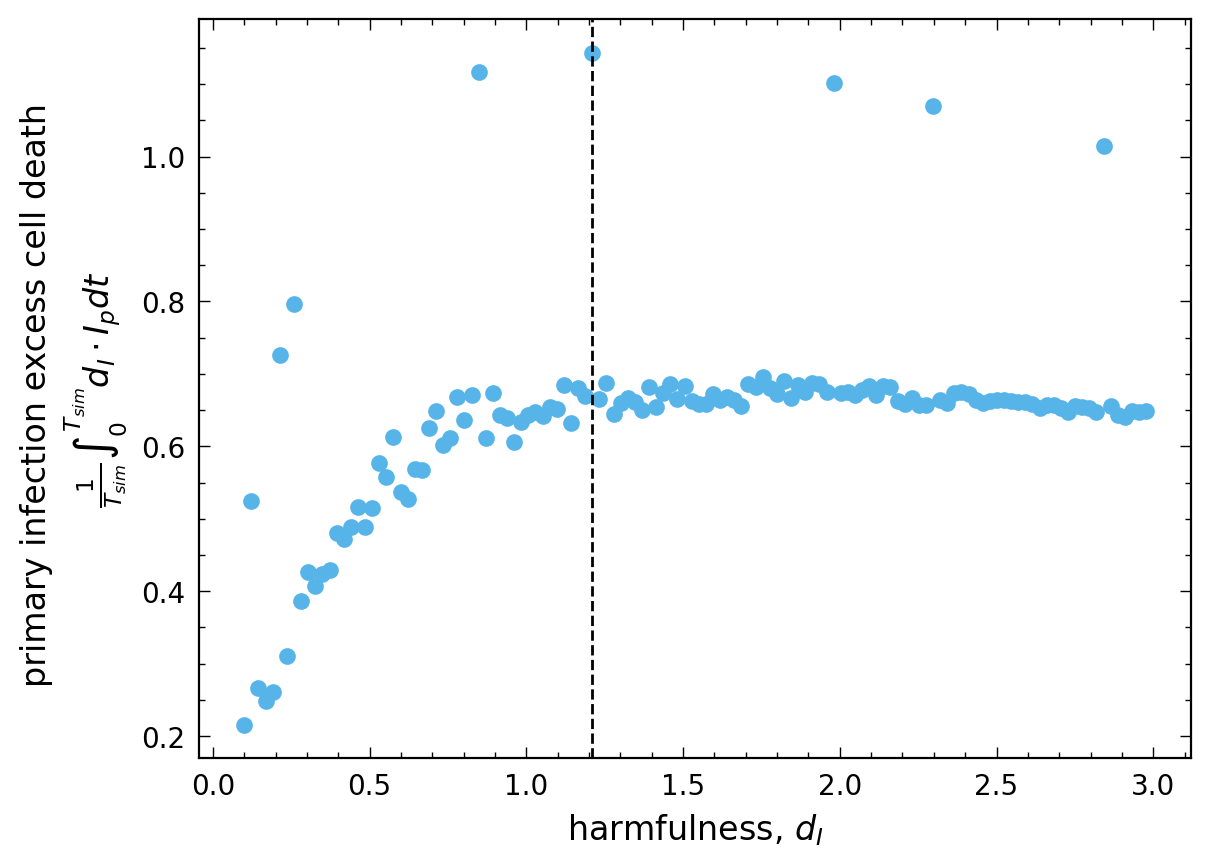

In [61]:
plt.scatter(dI_N0s[:,0], run_data_INs[:,15]/b_S)
plt.axvline(x = run_data_INs[:,7][np.argmax(run_data_INs[:,15])], color = 'k', linestyle = '--')
plt.xlabel('harmfulness, '+stat_names[7])
plt.ylabel('primary infection excess cell death \n'+stat_names[15])
print(run_data_INs[:,7][np.argmax(run_data_INs[:,15])])

0.30390625


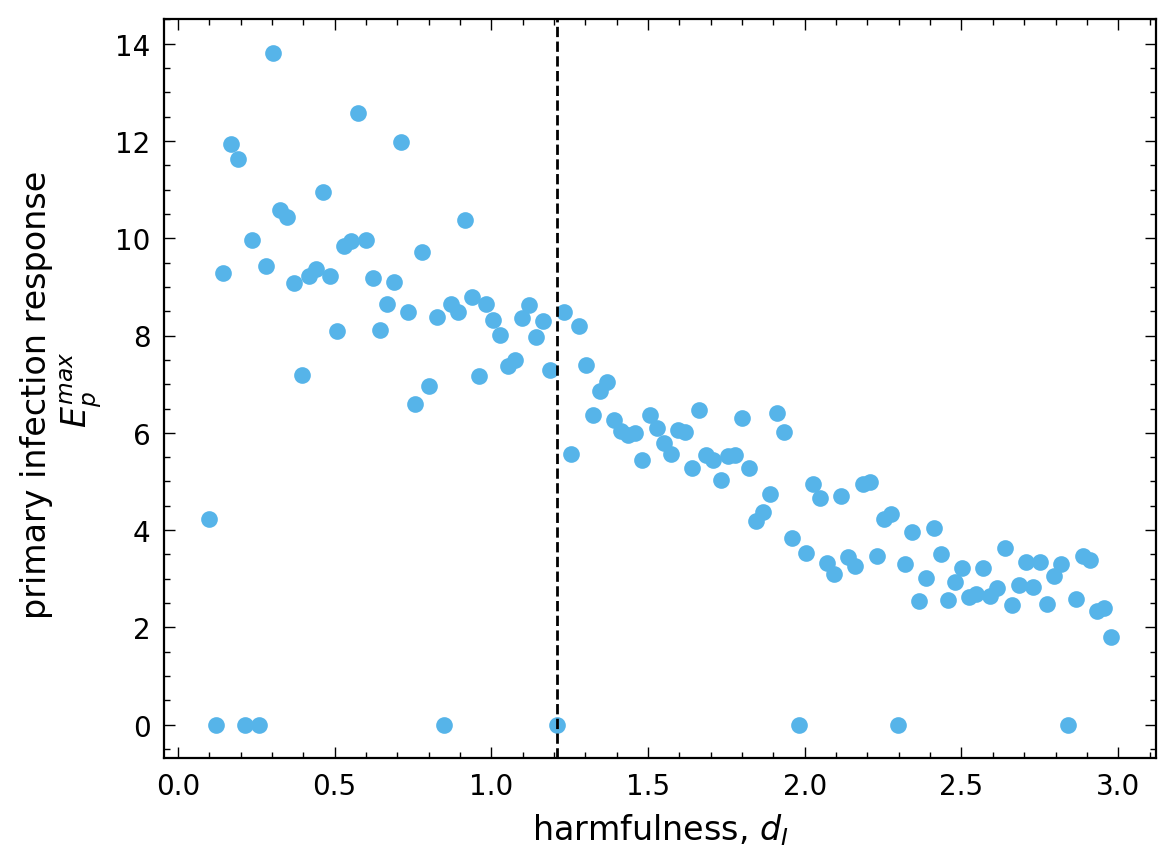

In [62]:
plt.scatter(dI_N0s[:,0], run_data_INs[:,19]/K_IE)
plt.axvline(x = run_data_INs[:,7][np.argmax(run_data_INs[:,15])], color = 'k', linestyle = '--')
plt.xlabel('harmfulness, '+stat_names[7])
plt.ylabel('primary infection response \n'+stat_names[19])
print(run_data_INs[:,7][np.argmax(run_data_INs[:,19])])

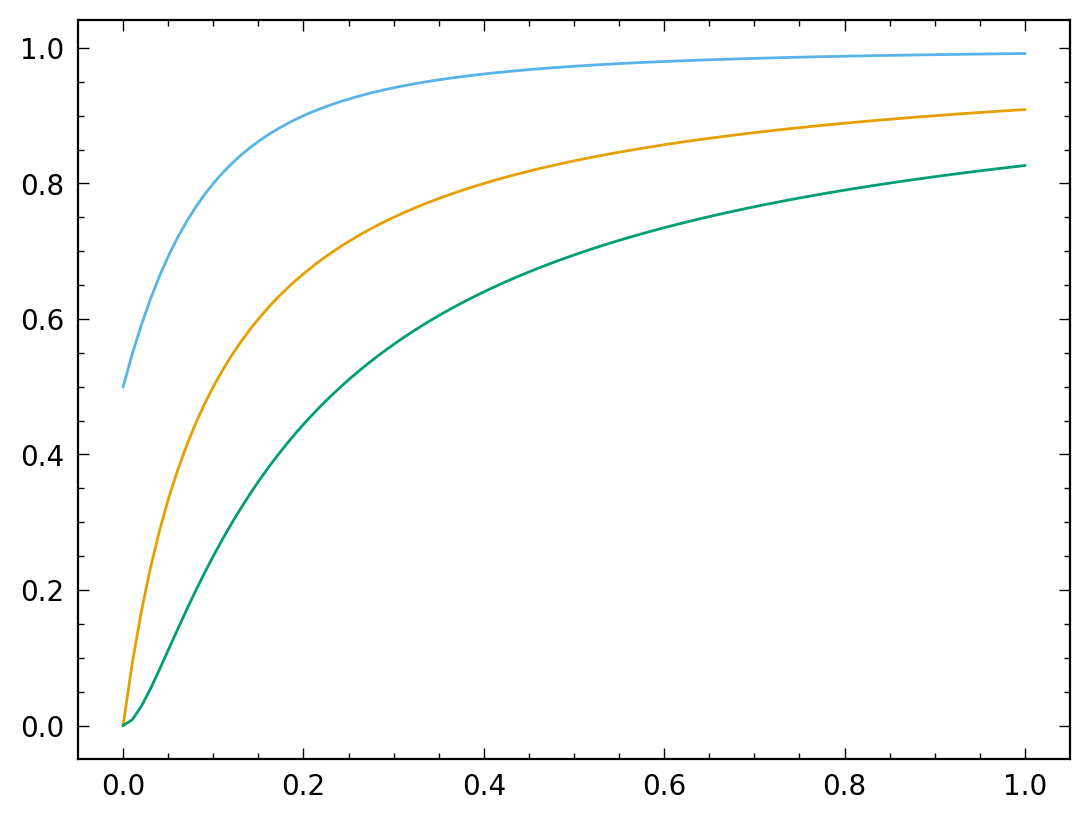

In [13]:
i, h = np.linspace(0,1,100), np.linspace(0,1,100)

plt.plot(i, p_XtoY(i,h,1,1,0,0.1,0.1, reg_model = "mwc_like"))
plt.plot(i, p_XtoY(i,h,2,2,0,0.1,0.1, reg_model = "hill_or"))
plt.plot(i, p_XtoY(i,h,2,2,0,0.1,0.1, reg_model = "hill_and"))

/mmfs1/home/oukogu/github/infoimmune/stoch_sim_model.py:199: RuntimeWarning: divide by zero encountered in reciprocal
  I_sig = I_stim**(psi_I)/(K_I**(psi_I) + I_stim**(psi_I))
/mmfs1/home/oukogu/github/infoimmune/stoch_sim_model.py:199: RuntimeWarning: invalid value encountered in divide
  I_sig = I_stim**(psi_I)/(K_I**(psi_I) + I_stim**(psi_I))
/mmfs1/home/oukogu/github/infoimmune/stoch_sim_model.py:200: RuntimeWarning: divide by zero encountered in reciprocal
  H_sig = H_stim**(psi_H)/(K_H**(psi_H) + H_stim**(psi_H))
/mmfs1/home/oukogu/github/infoimmune/stoch_sim_model.py:200: RuntimeWarning: invalid value encountered in divide
  H_sig = H_stim**(psi_H)/(K_H**(psi_H) + H_stim**(psi_H))
/mmfs1/home/oukogu/github/infoimmune/stoch_sim_model.py:193: RuntimeWarning: divide by zero encountered in reciprocal
  I_sig = I_stim**(psi_I)/(K_I**(psi_I) + I_stim**(psi_I))*(2.0 if psi_I == 0 else 1.0)
/mmfs1/home/oukogu/github/infoimmune/stoch_sim_model.py:193: RuntimeWarning: invalid value encou

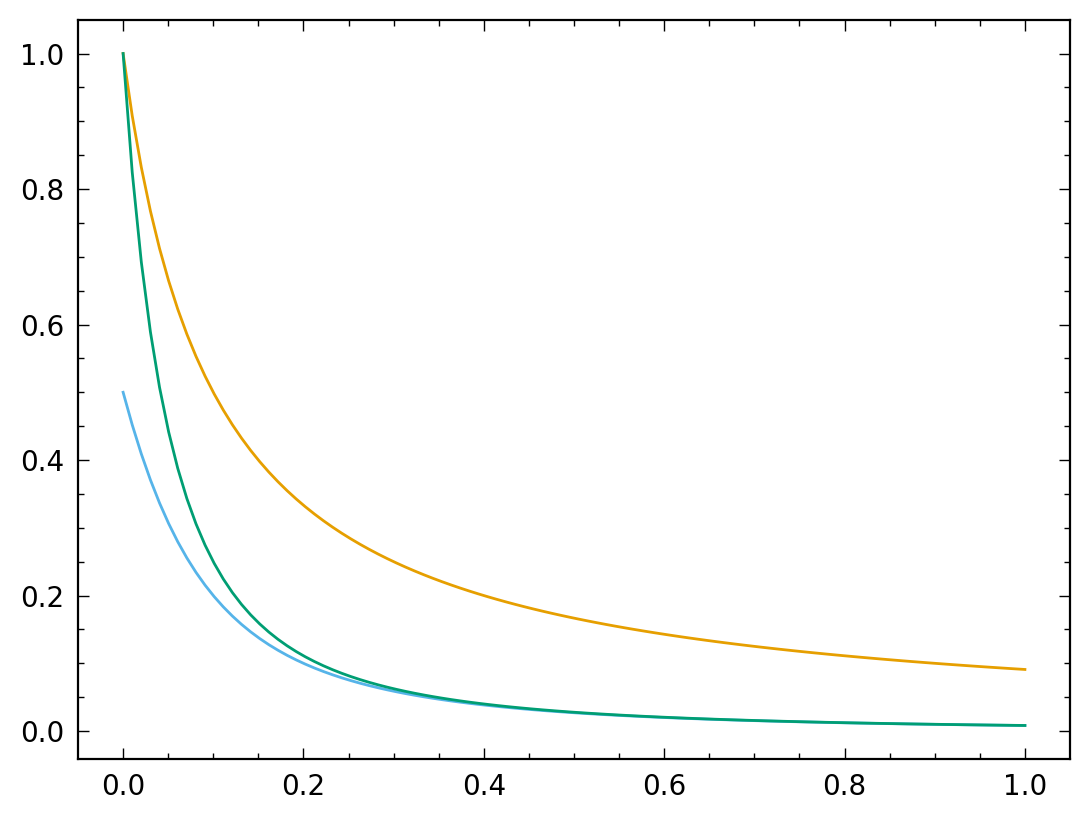

In [14]:
i, h = np.linspace(0,1,100), np.linspace(0,1,100)

plt.plot(i, p_XtoY(i,h,-1,-1,0,0.1,0.1, reg_model = "mwc_like"))
plt.plot(i, p_XtoY(i,h,-1,-1,0,0.1,0.1, reg_model = "hill_or"))
plt.plot(i, p_XtoY(i,h,-1,-1,0,0.1,0.1, reg_model = "hill_and"))

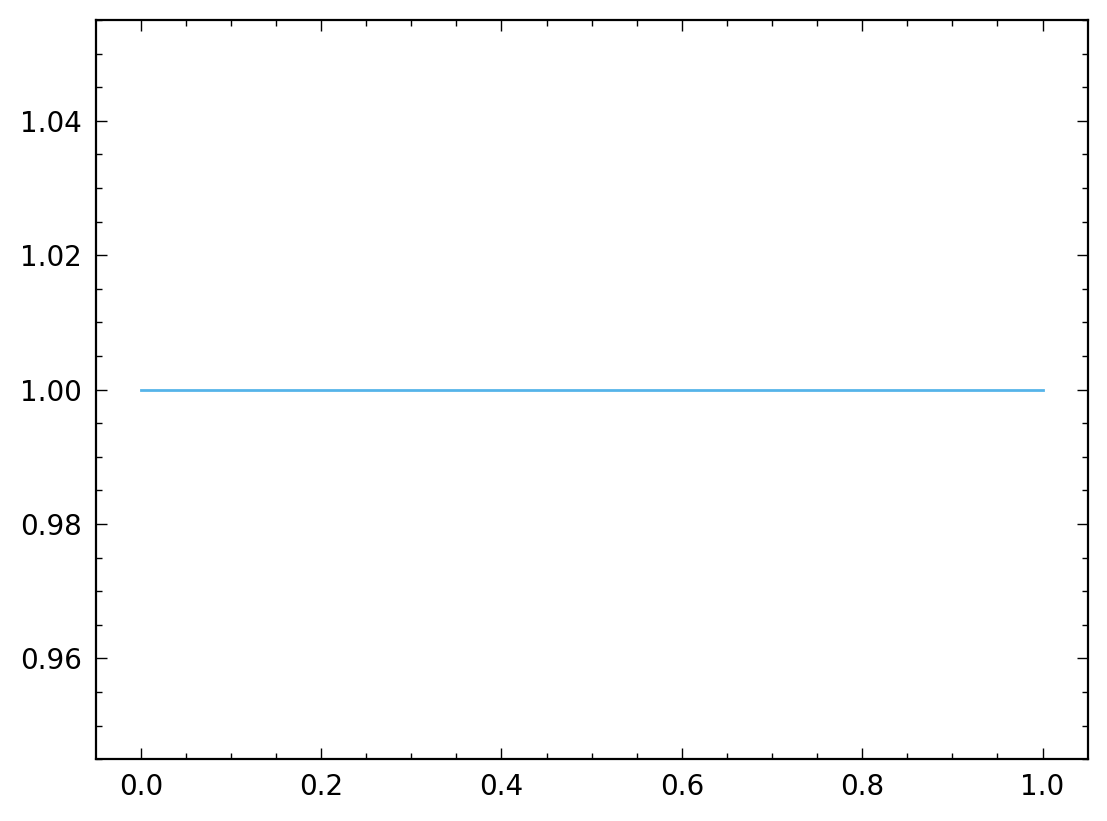

In [18]:
i, h = np.linspace(0,1,100), np.linspace(0,1,100)

#plt.plot(i, p_XtoY(i,h,0,0,0,0.1,0.1, reg_model = "mwc_like"))
#plt.plot(i, p_XtoY(i,h,0,0,0,0.1,0.1, reg_model = "hill_or"))
plt.plot(i, p_XtoY(i,h,0,0,0,0.1,0.1, reg_model = "hill_and"))

In [ ]:
# run_rates = np.zeros((runs, len(run_data[:,0][0]) ))
# run_data_Is = np.zeros((runs, len(run_data[:,1][0]) ))

# for i in np.arange(0,runs):
#     run_rates[i,:] = run_data[:,0][i]
#     run_data_Is[i,:] = run_data[:,1][i]

In [ ]:
# Compute max values in the data
r = 2*np.arange(9)
width = 1
plt.bar(r, np.amax(run_data_INs[:,-9:], axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r,stat_names[-9:], fontsize = 7)

plt.semilogy()
plt.suptitle('Max response')
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'response-max'+'.png', dpi=150)

In [ ]:
# # # Troubleshooting outliers
# print(run_data_Is[np.argmin(run_data_Is[:, 11]),:])
# print(run_data_Is[np.argmax(run_data_Is[:, 15]),:])
# immune_param= run_rates[np.argmax(run_data_Is[:, 15]), :]
# virus_param = (run_data_Is[np.argmax(run_data_Is[:, 15]), :])[6:10]

# rates, I, N, E, cM, eM, T, ts = stoch_sim(virus_param[0], virus_param[1], virus_param[2], virus_param[3],
#                                           rates = immune_param,
#                                           noise_model = "pop", 
#                                           rate_cv = [0.0, 0.0, 0.0, 0.0],
#                                           infection = infection_type)

# plt.plot(ts,np.array([I, E, cM]).T)
# plt.semilogy()
# # plt.plot(ts,np.array([p_A(tau_I,I)]).T)

# print(immune_param)

In [ ]:
# Compute minimum values in the data
r = 2*np.arange(9)
width = 1
plt.bar(r, np.amin(run_data_INs[:,-9:], axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r,stat_names[-9:], fontsize = 7)

plt.semilogy()
plt.suptitle('Min response')
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'response-min'+'.png', dpi=150)

## (4) Compute mutual information between variables

In [ ]:
# compute mutual information
MI_d_I = np.zeros(run_data_INs.shape[1])
for i in np.hstack(([7],np.arange(10,len(stat_names)))):
    MI_d_I[i] = calc_MI(run_data_INs[:,7], run_data_INs[:,i])

MI_N_0 = np.zeros(run_data_INs.shape[1])
for i in np.hstack(([8],np.arange(10,len(stat_names)))):
    MI_N_0[i] = calc_MI(run_data_INs[:,8], run_data_INs[:,i])

In [ ]:
# Plot Data Entropy
plt.figure(1)

r = np.arange(2)
width = 0.5
plt.bar(r, np.array([MI_d_I[7],MI_N_0[8]]), width = width)

plt.xlabel("antigen features")
plt.ylabel("Data Entropy")

plt.xticks(r,stat_names[7:9])
plt.suptitle(r'Entropy in generated data')
#plt.savefig("_figs/"+infection_type+'-'+'response-mutual-info-gauss-tau_I-'+str(tau_I)+'.png', dpi=150, bbox_inches="tight")

In [ ]:
# Plot mutual information
plt.figure(figsize=(6,3))

r = 2*np.arange(len(MI_d_I[10:]))
width = 0.5
plt.bar(r, MI_d_I[10:], width = width, label = r'harmfulness, $b_{I}$')
plt.bar(r + width, MI_N_0[10:], width = width, label = r'antigenicity, $N_0\cdot\langle p_{tcr}\rangle$')


plt.xlabel("response statistics", fontsize = 12)
plt.ylabel("mutual info. (bits)", fontsize = 12)

plt.xticks(r + width/2,stat_names[-9:],fontsize=8.5)
plt.legend(loc='upper right')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
#plt.suptitle(r'MI (bits) between $b_{I}, \tau_I,$ and response')
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'response-mutual-info-gr-harm.png', dpi=300, bbox_inches="tight")

## (5) Plot trajectories from simulations

In [ ]:
# Plot trajectories for d_I

# fig_d_I.suptitle(r'Immune response varying $b_{a_1}$ (Gaussian), $\tau_I=$ '+str(tau_I))
# plt.show()
# fig_d_I.savefig('plot-response-varying-d_I-gauss-tau_I-'+str(tau_I)+'.png', dpi=150)
ylabels=stat_names[-9:]
xlabels = [stat_names[7]]*len(ylabels)

fig_d_I = joint_plot_grid([run_data_INs[:,7]]* len(ylabels), run_data_INs[:,10:].T.tolist(), granularity=50,
                use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

#fig_d_I.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'plot-response-varying-d_I.png', dpi=150,bbox_inches="tight")


In [ ]:
# Plot trajectories for tau_I
# fig_tau_I.suptitle(r'Immune response while varying $\tau_I$ (Gaussian), $\tau_I=$ '+str(tau_I))
# plt.show()
# fig_tau_I.savefig('plot-response-varying-tau_I-gauss-tau_I-'+str(tau_I)+'.png', dpi=150)
ylabels=stat_names[-9:]
xlabels = [stat_names[8]]*len(ylabels)

fig_tau_I = joint_plot_grid([run_data_INs[:,8]]*len(ylabels), run_data_INs[:,10:].T.tolist(), granularity=50, use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

fig_tau_I.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'plot-response-varying-tau_I.png', dpi=150)

In [ ]:
# plot surface plots
fig = plt.figure(figsize=(12,12),dpi = 150)

i = 1
num_points = np.minimum(run_data_INs.shape[0], 10000)

for val in stat_names[i+9:]:

    ax = fig.add_subplot(5, 2, i) #, projection='3d')
    # set the limits of the plot to the limits of the data
    img = ax.scatter(run_data_INs[:num_points, 7], run_data_INs[:num_points,8], c = run_data_INs[:num_points,i+9], cmap="coolwarm")
    ax.set(xlabel=r'harmfulness, $d_I$', ylabel=r'antigenicity, $\tau_I$')
    fig.colorbar(img,  shrink=0.5, aspect=8, label =val)

    i += 1
    
fig.suptitle(r'Response variables dependence on $d_I$ and $\tau_I$'+' for '+infection_type+". infection")
fig.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'response-distribution-gr-harm.png', dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()

In [ ]:
fig = plt.figure(figsize=(6,3))

# set the limits of the plot to the limits of the data
plt.scatter(run_data_INs[:10000,7], run_data_INs[:10000,8], c = run_data_INs[:10000, 10], cmap="coolwarm")
plt.xlabel(r'harmfulness, $d_I$', fontsize = 16)
plt.ylabel(r'antigenicity, $\tau_I$', fontsize = 16)
plt.semilogx()
plt.colorbar(shrink=0.5, aspect=10, label ="pathogen load\n "+stat_names[10])
    
#fig.suptitle(r'Response variables dependence on $d_I$ and $\tau_I$'+' for '+infection_type+". infection")
fig.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'effectiveness-distribution-gr-harm.png', dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()